In [1]:
import pandas as pd

file = "/Users/esther/PycharmProjects/ad_proteomic_clock/results/3M_DEP_results.xlsx"

In [2]:
# Import comparison results
comparisons = ['5M', '8M', '14M', '20M', '26M']

dep_results = {}
for t in comparisons:
    sheet_name = f"3M_vs_{t}"
    dep_results[t] = pd.read_excel(file, sheet_name=sheet_name, index_col=0)

# Check input
for t in comparisons:
    print(t, dep_results[t].shape, dep_results[t].columns.tolist())

5M (4122, 3) ['p_value', 'logFC', 'neglog10pval']
8M (4122, 3) ['p_value', 'logFC', 'neglog10pval']
14M (4122, 3) ['p_value', 'logFC', 'neglog10pval']
20M (4122, 3) ['p_value', 'logFC', 'neglog10pval']
26M (4122, 3) ['p_value', 'logFC', 'neglog10pval']


In [3]:
# Filter proteins that are significant at one or more comparisons
timepoints = ['5M', '8M', '14M', '20M', '26M']

logfc_matrix = pd.DataFrame({t: dep_results[t]['logFC'] for t in timepoints})
pval_matrix = pd.DataFrame({t: dep_results[t]['p_value'] for t in timepoints})

signf_thresh = pval_matrix < 0.05
n_signf = signf_thresh.sum(axis=1)

signf_proteins = n_signf[n_signf > 0].index

print(f"{len(signf_proteins)} proteins significant at one or more timepoints")

825 proteins significant at one or more timepoints


In [7]:
# Classify trajectories into different categories
def classify_trajectory(row_mask):
    signf_indices = [i for i, v in enumerate(row_mask) if v]
    if len(signf_indices) == 0:
        return 'never'
    if len(signf_indices) == len(row_mask):
        return 'always'

    # Check if significant indices are contiguous
    is_contiguous = signf_indices == list(range(signf_indices[0], signf_indices[-1] + 1))
    if not is_contiguous:
        return 'intermittent'
    if signf_indices[0] == 0:
        return 'early_then_drop'
    elif signf_indices[-1] == len(row_mask) - 1:
        return 'late_onset'
    else:
        return 'transient_middle'

patterns = signf_thresh.loc[signf_proteins, timepoints].apply(
    lambda row: classify_trajectory(row.tolist()), axis=1)

print(patterns.value_counts())


transient_middle    451
late_onset          169
early_then_drop     109
intermittent         91
always                5
Name: count, dtype: int64


In [10]:
# Apply classification method
n_signf = signf_thresh.loc[signf_proteins, timepoints].sum(axis=1)

combined = pd.DataFrame(index=signf_proteins)
combined['n_significant'] = n_signf
combined['pattern'] = patterns

for t in timepoints:
    combined[f'logFC_{t}'] = logfc_matrix.loc[signf_proteins, t]
    combined[f'pval_{t}'] = pval_matrix.loc[signf_proteins, t]

pattern_order = ['always', 'late_onset', 'early_then_drop', 'transient_middle', 'intermittent', 'never']
combined['pattern'] = pd.Categorical(combined['pattern'], categories=pattern_order, ordered=True)

combined = combined.sort_values(['pattern', 'n_significant'], ascending=[True, False])

print(combined.head(20))

# Save in Excel
with pd.ExcelWriter("/Users/esther/PycharmProjects/ad_proteomic_clock/results/3M_DEP_trajectory.xlsx") as writer:
    combined.to_excel(writer, sheet_name="trajectory_ranked")

         n_significant     pattern  logFC_5M   pval_5M  logFC_8M   pval_8M  \
protein                                                                      
P16254               5      always -0.482995  0.005281 -0.410874  0.002162   
P80314               5      always -0.270948  0.017050 -0.309585  0.024334   
Q6PAR5               5      always -0.631453  0.006732 -0.577808  0.017752   
Q91V36               5      always -0.391108  0.035101 -0.429810  0.038995   
Q9JJI8               5      always -0.343035  0.017006 -0.360707  0.033228   
P62071               4  late_onset -0.145789  0.360490 -0.538167  0.006868   
P70677               4  late_onset -0.632170  0.095681 -0.610055  0.008980   
P97492               4  late_onset -0.125651  0.331581 -0.258340  0.039594   
Q64727               4  late_onset  0.159102  0.124853  0.277486  0.002389   
Q8R105               4  late_onset -0.661675  0.242687 -1.184461  0.048614   
Q9D173               4  late_onset -0.498581  0.057201 -0.582543

In [23]:
with pd.ExcelWriter("/Users/esther/PycharmProjects/ad_proteomic_clock/results/3M_DEP_trajectory.xlsx",
                     mode='a', if_sheet_exists='replace') as writer:
    combined.to_excel(writer, sheet_name="trajectory_ranked")

In [19]:
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

data = pd.read_excel("/Users/esther/PycharmProjects/ad_proteomic_clock/training_data/JPST003472.xlsx").set_index("sample_id")
print(data.shape)

(45, 4122)


In [21]:
# Calculate function of age
# Extract age from sample_id
age = pd.Series(data.index.str.extract(r'(\d+)M')[0].astype(float).values, index=data.index)
print(age.value_counts())

print(data.shape)
# Correlate each significant protein w/ continuous age
def spearman_corr(protein_list, data, age):
    age_correlations = {}
    for protein in protein_list:
        rho, p = spearmanr(data[protein], age)
        age_correlations[protein] = {'spearman_r': rho, 'spearman_p': p}

    df = pd.DataFrame(age_correlations).T

    # FDR correction
    reject, qvals, _, _ = multipletests(df['spearman_p'], method='fdr_bh')
    df['spearman_q'] = qvals
    df['fdr_significant'] = reject
    df['raw_significant'] = df['spearman_p'] < 0.05
    df = df.sort_values('spearman_r', key=abs, ascending=False)
    return df

# Output Spearman corr.
age_corr_signf = spearman_corr(signf_proteins, data, age)
age_corr_all = spearman_corr(data.columns, data, age)

print(f"DEP-flagged proteins: {len(age_corr_signf)}, "
      f"{age_corr_signf['raw_significant'].sum()} pass raw p<0.05")
print(f"All proteins: {len(age_corr_all)}, "
      f"{age_corr_all['raw_significant'].sum()} pass raw p<0.05")

# Save to Excel
with pd.ExcelWriter("/Users/esther/PycharmProjects/ad_proteomic_clock/results/3M_DEP_trajectory.xlsx", mode='a', if_sheet_exists='replace') as writer:
    age_corr_signf.to_excel(writer, sheet_name="spearman_DEP_proteins")
    age_corr_all.to_excel(writer, sheet_name="spearman_all_proteins")

14.0    9
5.0     9
8.0     8
20.0    7
3.0     7
26.0    5
Name: count, dtype: int64
(45, 4122)
DEP-flagged proteins: 825, 211 pass raw p<0.05
All proteins: 4122, 319 pass raw p<0.05


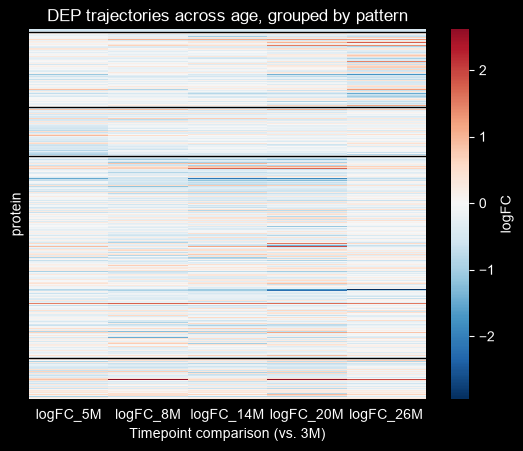

In [28]:
# Heatmap across timepoints
import seaborn as sns
import matplotlib.pyplot as plt

timepoints = ['5M', '8M', '14M', '20M', '26M']
cols = [f'logFC_{t}' for t in timepoints]

heatmap_data = combined[cols].copy()

plt.figure()
sns.heatmap(heatmap_data, cmap='RdBu_r', center=0, cbar_kws={'label': 'logFC'}, yticklabels=False)

# Separate pattern groups
pattern_boundaries = combined['pattern'].ne(combined['pattern'].shift()).cumsum()
boundary_position = pattern_boundaries.drop_duplicates().index
for p in [combined.index.get_loc(i) for i in boundary_position[1:]]:
    plt.axhline(p, color='black', linewidth=1)

plt.title('DEP trajectories across age, grouped by pattern')
plt.xlabel('Timepoint comparison (vs. 3M)')
plt.show()

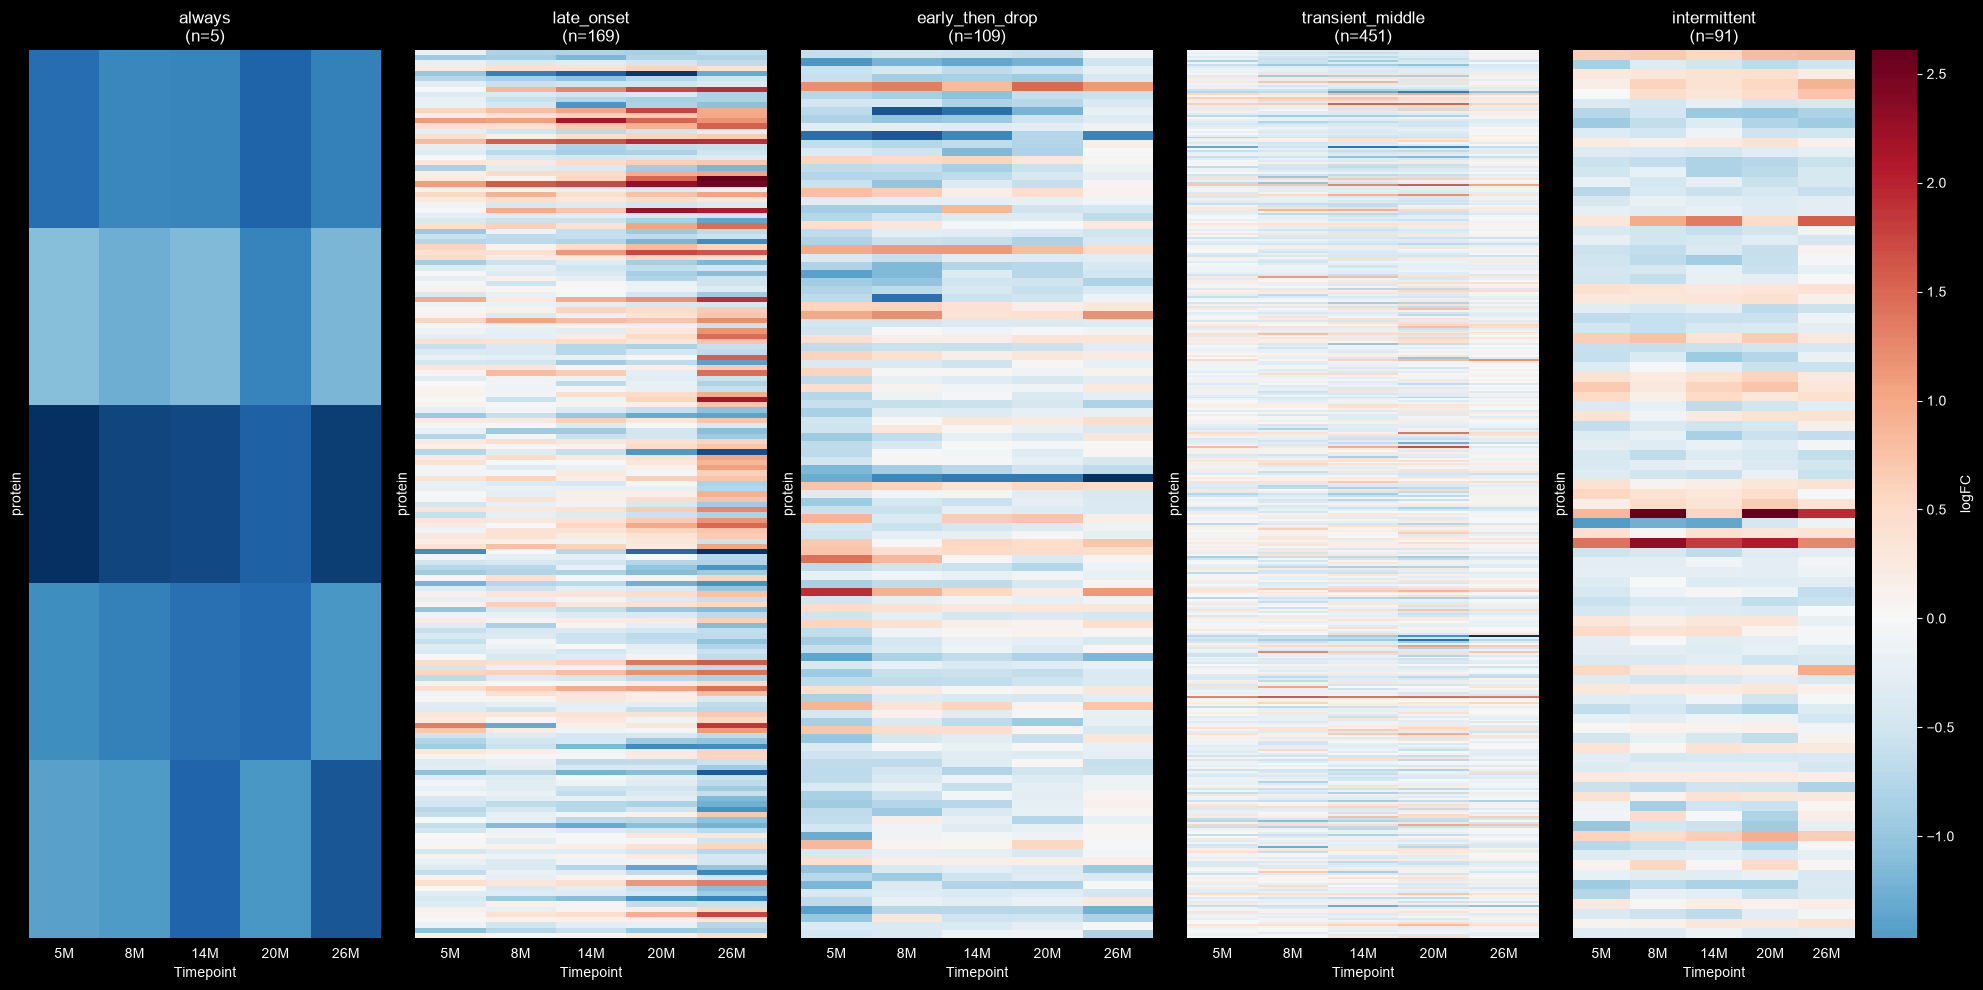

In [30]:
# Separate heatmaps per pattern
patterns_present = [p for p in pattern_order if p in combined['pattern'].unique()]

fig, axes = plt.subplots(1, len(patterns_present),
                          figsize=(4 * len(patterns_present), 10),
                          sharey=False)

if len(patterns_present) == 1:
    axes = [axes]

for ax, pattern in zip(axes, patterns_present):
    subset = combined[combined['pattern'] == pattern]
    heatmap_data = subset[cols].copy()
    heatmap_data.columns = timepoints

    sns.heatmap(heatmap_data, cmap='RdBu_r', center=0,
                cbar=(ax == axes[-1]), cbar_kws={'label': 'logFC'},
                yticklabels=False, ax=ax)
    ax.set_title(f'{pattern}\n(n={len(subset)})')
    ax.set_xlabel('Timepoint')

plt.tight_layout()
plt.show()